# 11 · Regression through the time-series model

Follow the app's simple and multiple consumption regressions while preserving their training and forecast design.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Consumption and income
The frozen project contains 187 quarterly observations from 1970 through mid-2016.
`Simple Linear Regression` models Consumption using Income. It is stored as ARIMAX with AR, differencing and MA orders all zero.
The saved training length is 149 steps, the default-training flag remains enabled, and the forecast horizon is 30 steps.

,Series,Route,Type,Unit,Records,Start,End,Missing
0,Consumption,Manual,DailyDischarge,% Change in Consumption,187,1970-01-01T00:00:00.0000000,2016-07-01T00:00:00.0000000,0
1,Income,Manual,DailyDischarge,% Change in Income,187,1970-01-01T00:00:00.0000000,2016-07-01T00:00:00.0000000,0
2,Production,Manual,DailyDischarge,% Change in Production,187,1970-01-01T00:00:00.0000000,2016-07-01T00:00:00.0000000,0
3,Savings,Manual,DailyDischarge,% Change in Savings,187,1970-01-01T00:00:00.0000000,2016-07-01T00:00:00.0000000,0
4,Unemployment,Manual,DailyDischarge,% Change in Unemployment,187,1970-01-01T00:00:00.0000000,2016-07-01T00:00:00.0000000,0


,Setting,Saved choice
0,Analysis,ARIMAXAnalysis
1,TimeSeriesData,Consumption
2,Covariates,Income
3,ForecastingTimeSteps,30
4,BayesianAnalysis.Type,DEMCzs
5,BayesianAnalysis.NumberOfChains,6
6,BayesianAnalysis.ThinningInterval,30
7,BayesianAnalysis.WarmupIterations,1750
8,BayesianAnalysis.Iterations,3500
9,BayesianAnalysis.UseSimulationDefaults,True


,Parameter,Estimate,Fixed,Lower,Upper,Prior
0,Intercept (μ),0.581308,False,1.000000e-02,10.0,Numerics.Distributions.Uniform
1,Covariate (β₁),0.324730,False,-1.000000e+01,10.0,Numerics.Distributions.Uniform
2,Scale (σ),0.604545,False,1.110223e-16,10.0,Numerics.Distributions.Uniform


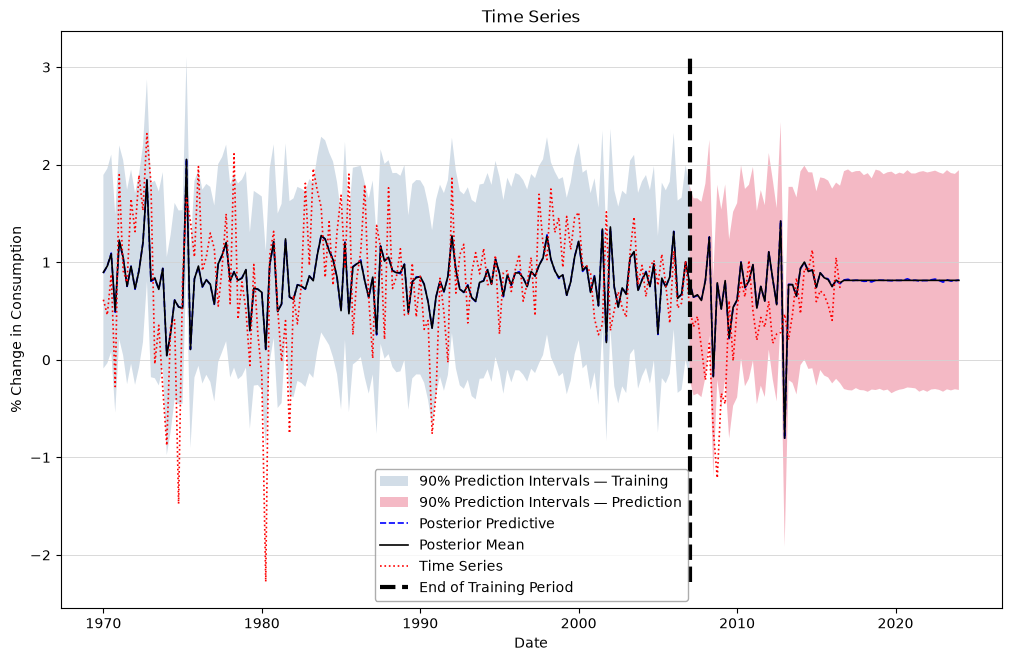

In [2]:
PROJECT = "time-series-regression-example"
display(series_inventory(load_project(PROJECT)))
simple = saved_case(PROJECT, "Simple Linear Regression", run=RUN_ANALYSES)
multiple = saved_case(PROJECT, "Multiple Linear Regression", run=RUN_ANALYSES)
display(simple.settings)
display(simple.parameters)
simple.show("series")

## Multiple regression
The second saved model adds Production, Savings and Unemployment to Income.
Use the aligned covariates and saved transformations. Coefficients are conditional associations under this model;
additional predictors do not by themselves establish causal effects or improve out-of-sample performance.
Both analyses use the saved `BlockBootstrap` covariate-extension method for their 30-step future horizon. Each covariate is resampled separately, preserving within-series blocks but not synchronized cross-covariate dependence. Deterministic predictions extend each covariate with its mean. Residual horizontal coordinates are observation dates, displayed on a Date axis.

,Setting,Saved choice
0,Analysis,ARIMAXAnalysis
1,TimeSeriesData,Consumption
2,Covariates,Income|Production|Savings|Unemployment
3,ForecastingTimeSteps,30
4,BayesianAnalysis.Type,DEMCzs
5,BayesianAnalysis.NumberOfChains,12
6,BayesianAnalysis.ThinningInterval,60
7,BayesianAnalysis.WarmupIterations,1750
8,BayesianAnalysis.Iterations,3500
9,BayesianAnalysis.UseSimulationDefaults,True


,Parameter,Estimate,Fixed,Lower,Upper,Prior
0,Intercept (μ),0.305089,False,1.000000e-02,10.0,Numerics.Distributions.Uniform
1,Covariate (β₁),0.703551,False,-1.000000e+01,10.0,Numerics.Distributions.Uniform
2,Covariate (β₂),0.036723,False,-1.000000e+01,10.0,Numerics.Distributions.Uniform
3,Covariate (β₃),-0.047047,False,-1.000000e+01,10.0,Numerics.Distributions.Uniform
4,Covariate (β₄),-0.274178,False,-1.000000e+01,10.0,Numerics.Distributions.Uniform
5,Scale (σ),0.348938,False,1.110223e-16,10.0,Numerics.Distributions.Uniform


,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,Simple Linear Regression,see saved dependencies,ARIMAXAnalysis,275.670652,284.682491,275.582088,0.598081,,"Comparable: same Consumption response, aligned..."
1,Multiple Linear Regression,see saved dependencies,ARIMAXAnalysis,114.500283,132.523961,114.447139,0.341147,,"Comparable: same Consumption response, aligned..."


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,Simple Linear Regression,saved-app,sha256:d84276fb50bc,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
1,Multiple Linear Regression,saved-app,sha256:d84276fb50bc,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt


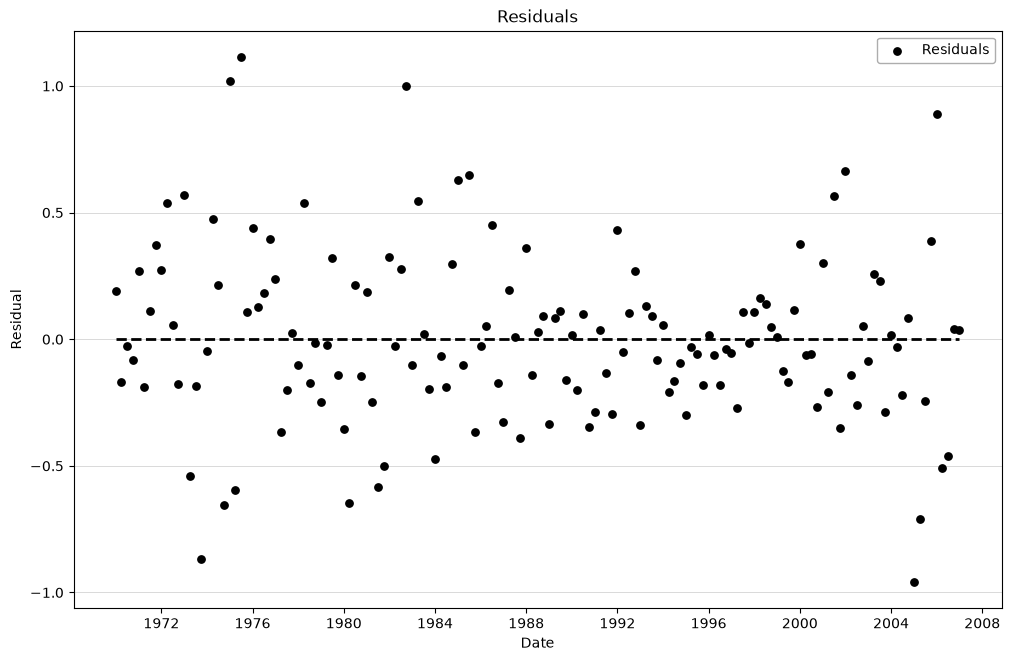

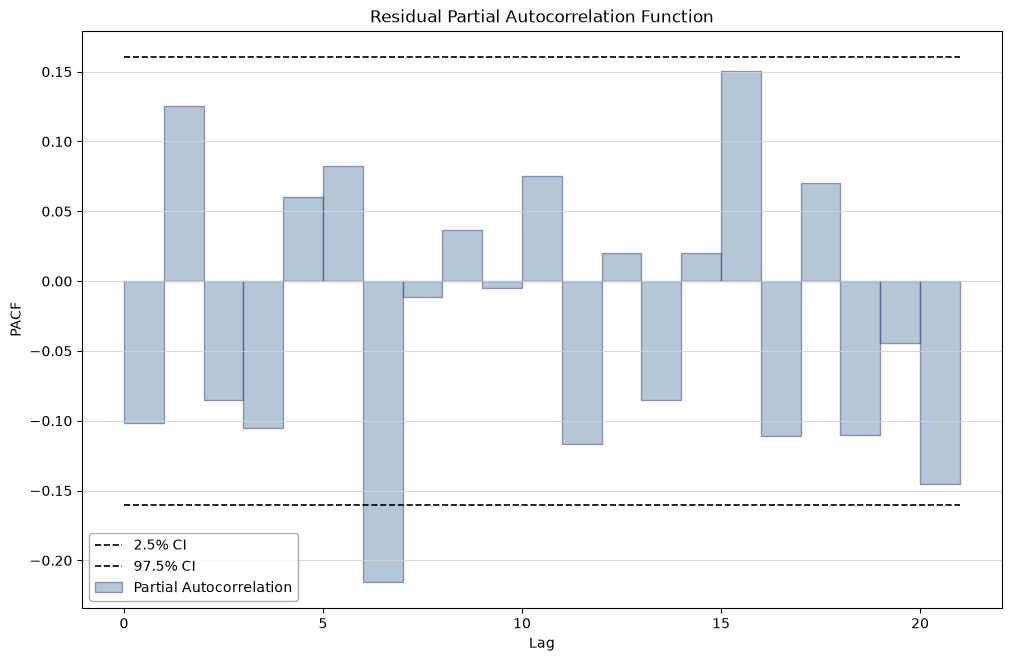

In [3]:
display(multiple.settings)
display(multiple.parameters)
display(case_metrics([simple, multiple], comparison_scope="Comparable: same Consumption response, aligned observations, and ARIMAX likelihood."))
display(case_provenance([simple, multiple]))
multiple.show("residuals")
multiple.show("residual_pacf")

## Read the fit and forecast together
The app's training/prediction bands, residual distribution and serial-correlation diagnostics complement one another.
A persistent residual pattern motivates a separate model question; this walkthrough preserves the original zero-AR/MA regression examples.
All six time-series plots and shared sampler diagnostics are available through each saved case and the plot gallery.